In [2]:
pip install pandas pyreadstat numpy

  Using cached pyreadstat-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (1.2 kB)
  Using cached numpy-2.4.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached narwhals-2.17.0-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.9 MB/s  0:00:02 eta 0:00:01
Using cached pyreadstat-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (522 kB)
Using cached numpy-2.4.2-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
Using cached narwhals-2.17.0-py3-none-any.whl (444 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pandas]2m3/4 [pandas]s]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

os.listdir("/Users/theogengineer/Desktop/diabetes-risk-project/data_raw")

['LLCP2015.XPT']

In [3]:
os.listdir("/Users/theogengineer/Desktop/diabetes-risk-project/data_raw")

['LLCP2015.XPT']

In [1]:
import pandas as pd

df = pd.read_sas("../data_raw/LLCP2015.XPT")

print(df.shape)

(441456, 330)


In [ ]:
df.columns.tolist()

In [ ]:
[c for c in df.columns if "DIABET" in c]

In [ ]:
[c for c in df.columns if "BMI" in c]

In [ ]:
[c for c in df.columns if "BPHIGH" in c]

In [ ]:
[c for c in df.columns if "GENHLTH" in c]

In [ ]:
[c for c in df.columns if "MENTHLTH" in c]

In [ ]:
[c for c in df.columns if any(x in c for x in ["DIAB","BMI","AGE","SMOK","CHOL","BP","HLTH"])]

In [2]:
columns = [
"DIABETE3",
"_BMI5",
"_AGEG5YR",
"BPHIGH4",
"SMOKE100",
"_RFCHOL",
"_TOTINDA",
"GENHLTH",
"MENTHLTH"
]

df = df[columns]

df.head()

,DIABETE3,_BMI5,_AGEG5YR,BPHIGH4,SMOKE100,_RFCHOL,_TOTINDA,GENHLTH,MENTHLTH
0,3.0,4018.0,9.0,1.0,1.0,2.0,2.0,5.0,18.0
1,3.0,2509.0,7.0,3.0,1.0,1.0,1.0,3.0,88.0
2,3.0,2204.0,11.0,3.0,NaN,2.0,9.0,4.0,88.0
3,3.0,2819.0,9.0,1.0,2.0,2.0,2.0,5.0,30.0
4,3.0,2437.0,9.0,3.0,2.0,1.0,2.0,5.0,88.0


In [3]:
df = df.rename(columns={

"DIABETE3":"diabetes",
"_BMI5":"bmi",
"_AGEG5YR":"age_group",
"BPHIGH4":"high_bp",
"SMOKE100":"smoker",
"_RFCHOL":"high_cholesterol",
"_TOTINDA":"physical_activity",
"GENHLTH":"general_health",
"MENTHLTH":"mental_health"

})

In [ ]:
df.head()

In [4]:
df["bmi"] = df["bmi"] / 100

In [ ]:
# ── Fix: BRFSS 2015 DIABETE3 coding ──────────────────────────────────────
# 1 = Yes (has diabetes)
# 2 = Yes, but female told only during pregnancy  ← was incorrectly kept as "No"
# 3 = No (not diabetic)                           ← was incorrectly EXCLUDED
# 4 = No, pre-diabetes or borderline
#
# PREVIOUS BUG: isin([1, 2]) kept only diabetic respondents,
# excluding all non-diabetic people (value 3).

df = df[df["diabetes"].isin([1, 3])]

df["diabetes"] = df["diabetes"].replace({
    1: 1,   # Yes → 1
    3: 0    # No  → 0
})

In [ ]:
# ── Recode BRFSS categoricals to clean binary (0/1) ──────────────────────

# BPHIGH4: 1=Yes, 2=Yes(preg), 3=No, 4=Borderline → 1=Yes, 0=No
df["high_bp"] = df["high_bp"].map({1: 1, 2: 1, 3: 0, 4: 1})

# SMOKE100: 1=Yes, 2=No → 1/0
df["smoker"] = df["smoker"].map({1: 1, 2: 0})

# _RFCHOL: 1=No risk, 2=Yes high cholesterol → 0/1
df["high_cholesterol"] = df["high_cholesterol"].map({1: 0, 2: 1})

# _TOTINDA: 1=Active, 2=Inactive → 1/0
df["physical_activity"] = df["physical_activity"].map({1: 1, 2: 0})

# MENTHLTH: 1-30 days, 88=None → recode 88 to 0
df["mental_health"] = df["mental_health"].replace(88, 0)

# GENHLTH: 1-5 valid, 7=Don't know, 9=Refused → NA
df["general_health"] = df["general_health"].replace([7, 9], pd.NA)

# _AGEG5YR: 1-13 valid, 14=Don't know → NA
df["age_group"] = df["age_group"].replace(14, pd.NA)

# Drop any rows with missing values
df = df.dropna()

print(f"Clean dataset shape: {df.shape}")
print(f"Diabetes prevalence: {df['diabetes'].mean():.3f} ({df['diabetes'].mean()*100:.1f}%)")
print(f"\nClass distribution:")
print(df["diabetes"].value_counts())

In [ ]:
df.shape

In [ ]:
df["diabetes"].value_counts()

In [ ]:
import matplotlib.pyplot as plt

df["diabetes"].value_counts().plot(kind="bar")
plt.show()

In [ ]:
df.to_csv("../data_processed/brfss_diabetes_clean.csv", index=False)

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
pip install imbalanced-learn

In [ ]:
pip uninstall scikit-learn -y

In [ ]:
pip uninstall scikit-learn -y

In [ ]:
pip install scikit-learn

In [ ]:
import sklearn
print(sklearn.__file__)

In [ ]:
pip install scikit-learn

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000))
])

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

In [ ]:
from sklearn.utils import resample

df_majority = df[df.diabetes == 1]
df_minority = df[df.diabetes == 0]

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

In [ ]:
df_balanced["diabetes"].value_counts()

In [ ]:
X = df_balanced.drop("diabetes", axis=1)
y = df_balanced["diabetes"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
df.shape

In [ ]:
df["diabetes"].value_counts()

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape
X_test.shape

In [ ]:
y_train.value_counts()

In [ ]:
from sklearn.utils import resample
import pandas as pd

In [ ]:
train_df = pd.concat([X_train, y_train], axis=1)

In [ ]:
majority = train_df[train_df.diabetes == 1]
minority = train_df[train_df.diabetes == 0]

In [ ]:
majority.shape
minority.shape

In [ ]:
majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

In [ ]:
train_balanced = pd.concat([majority_downsampled, minority])

In [ ]:
train_balanced["diabetes"].value_counts()

In [ ]:
X_train_bal = train_balanced.drop("diabetes", axis=1)
y_train_bal = train_balanced["diabetes"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_bal, y_train_bal)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc_auc)

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()

In [7]:
df["bmi_age"] = df["bmi"] * df["age_group"]

df["bmi_bp"] = df["bmi"] * df["high_bp"]

df["age_bp"] = df["age_group"] * df["high_bp"]

df["chol_bmi"] = df["high_cholesterol"] * df["bmi"]

df["health_bmi"] = df["general_health"] * df["bmi"]

In [8]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:

import numpy as np

# ── Step 1: Fix dtypes (pd.NA leaves object columns; XGBoost requires float) ──
X_train = X_train.apply(pd.to_numeric, errors="coerce").astype(np.float64)
X_test  = X_test.apply(pd.to_numeric, errors="coerce").astype(np.float64)
y_train = y_train.astype(np.float64)
y_test  = y_test.astype(np.float64)
X_numeric = X.apply(pd.to_numeric, errors="coerce").astype(np.float64)
y_numeric = y.astype(np.float64)

# ── Step 2: Compute scale_pos_weight (replaces manual downsampling) ───────────
# XGBoost handles class imbalance natively via scale_pos_weight.
# Formula: count(negative) / count(positive)
# Tells the model how many times more to penalise misclassifying the minority.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Dtypes (sample):", X_train.dtypes.unique())
print(f"\nTraining set class counts")
print(f"  Positive (diabetes=1) : {pos:,.0f}")
print(f"  Negative (diabetes=0) : {neg:,.0f}")
print(f"  scale_pos_weight      : {scale_pos_weight:.4f}")
print(f"\nFull training set retained ({len(y_train):,.0f} rows) — no samples dropped.")


Dtypes (sample): [dtype('float64')]

Training set class counts
  Positive (diabetes=1) : 28,465
  Negative (diabetes=0) : 1,559
  scale_pos_weight      : 0.0548

Full training set retained (30,024 rows) — no samples dropped.


In [35]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean AUC:", scores.mean())

In [ ]:
pip install xgboost

In [36]:

# --- XGBoost Model Training with scale_pos_weight + Early Stopping ---
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # native class-imbalance handling
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"\nBest iteration : {xgb.best_iteration}")
print(f"Best AUC       : {xgb.best_score:.4f}")
print(f"scale_pos_weight used: {scale_pos_weight:.4f}")


[0]	validation_0-auc:0.86299
[50]	validation_0-auc:0.87683
[75]	validation_0-auc:0.87654

Best iteration : 25
Best AUC       : 0.8790
scale_pos_weight used: 0.0548


In [37]:

# Dtype conversion is handled earlier in the scale_pos_weight cell.
# Verify shapes here for reference.
print(f"Shapes: train={X_train.shape}, test={X_test.shape}")
print(f"Dtypes OK: {X_train.dtypes.unique()}")


Shapes: train=(30024, 13), test=(7506, 13)
Dtypes OK: [dtype('float64')]


In [38]:
# --- XGBoost Predictions & Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=" * 40)
print("XGBoost Evaluation Results")
print("=" * 40)
print(f"\nROC AUC: {roc_auc_xgb:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_xgb)}")

XGBoost Evaluation Results

ROC AUC: 0.8790

Confusion Matrix:
[[ 302   88]
 [ 948 6168]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.24      0.77      0.37       390
         1.0       0.99      0.87      0.92      7116

    accuracy                           0.86      7506
   macro avg       0.61      0.82      0.65      7506
weighted avg       0.95      0.86      0.89      7506



In [39]:

# ============================================================
# PROBABILITY CALIBRATION
# ============================================================
# XGBoost was trained on a downsampled (50/50) dataset for class balance.
# This inflates raw probabilities relative to the true prevalence (~14%).
# Isotonic regression calibration maps raw scores → real probabilities.
#
# Approach: split the held-out test set in half
#   - calibration set  → fit the calibrator (never seen by XGBoost during training)
#   - evaluation set   → unbiased assessment of calibrated model

from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Split test set 50/50
n_cal = len(X_test) // 2
X_cal,  X_eval  = X_test.iloc[:n_cal],  X_test.iloc[n_cal:]
y_cal,  y_eval  = y_test.iloc[:n_cal],  y_test.iloc[n_cal:]

# Fit isotonic regression: raw XGBoost scores → fraction of positives
raw_probs_cal = xgb.predict_proba(X_cal)[:, 1]
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(raw_probs_cal, y_cal)

# Wrap into a sklearn-compatible calibrated model
class IsotonicCalibratedXGB:
    """Thin wrapper: passes raw XGBoost probabilities through an isotonic calibrator."""
    def __init__(self, base_model, calibrator):
        self.base_model = base_model
        self.calibrator = calibrator

    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.calibrator.predict(raw)
        return np.column_stack([1.0 - cal, cal])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

calibrated_xgb = IsotonicCalibratedXGB(xgb, iso_reg)

# Brier scores on the held-out evaluation half
y_prob_raw_eval = xgb.predict_proba(X_eval)[:, 1]
y_prob_cal_eval = calibrated_xgb.predict_proba(X_eval)[:, 1]

brier_raw = brier_score_loss(y_eval, y_prob_raw_eval)
brier_cal = brier_score_loss(y_eval, y_prob_cal_eval)
improvement = (brier_raw - brier_cal) / brier_raw * 100

print("=" * 50)
print("  Probability Calibration Complete")
print("=" * 50)
print(f"\n  Calibration set : {X_cal.shape[0]:,} samples")
print(f"  Evaluation set  : {X_eval.shape[0]:,} samples")
print(f"\n  Brier Score (lower = better)")
print(f"    Raw XGBoost : {brier_raw:.4f}")
print(f"    Calibrated  : {brier_cal:.4f}")
print(f"    Improvement : {improvement:.1f}%")
print(f"\n  Prevalence in eval set      : {y_eval.mean():.3f}")
print(f"  Mean raw predicted prob     : {y_prob_raw_eval.mean():.3f}")
print(f"  Mean calibrated predicted   : {y_prob_cal_eval.mean():.3f}")
print("\n  calibrated_xgb is ready.")


  Probability Calibration Complete

  Calibration set : 3,753 samples
  Evaluation set  : 3,753 samples

  Brier Score (lower = better)
    Raw XGBoost : 0.1556
    Calibrated  : 0.0343
    Improvement : 77.9%

  Prevalence in eval set      : 0.951
  Mean raw predicted prob     : 0.610
  Mean calibrated predicted   : 0.947

  calibrated_xgb is ready.


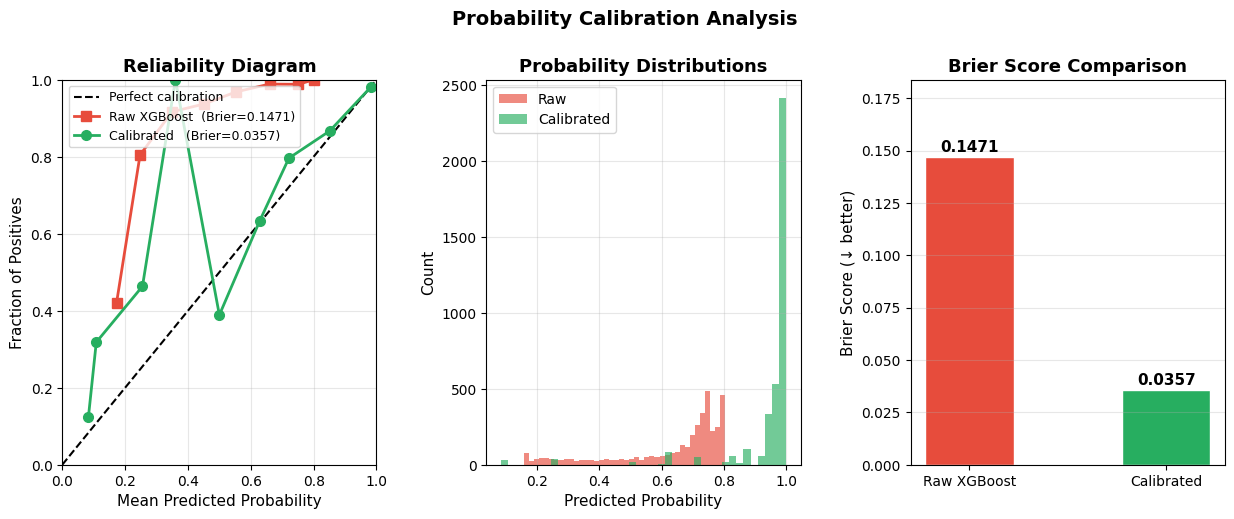


Note: AUC is preserved after calibration — only probability scale changes.


In [29]:

# ============================================================
# RELIABILITY DIAGRAM  (Calibration Curve)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Calibration curves
frac_pos_raw, mean_pred_raw = calibration_curve(y_eval, y_prob_raw_eval, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_eval, y_prob_cal_eval, n_bins=10)

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Panel 1: Reliability diagram ---
ax1 = fig.add_subplot(gs[0])
ax1.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration")
ax1.plot(mean_pred_raw, frac_pos_raw, "s-", color="#e74c3c",
         lw=2, ms=7, label=f"Raw XGBoost  (Brier={brier_raw:.4f})")
ax1.plot(mean_pred_cal, frac_pos_cal, "o-", color="#27ae60",
         lw=2, ms=7, label=f"Calibrated   (Brier={brier_cal:.4f})")
ax1.set_xlabel("Mean Predicted Probability", fontsize=11)
ax1.set_ylabel("Fraction of Positives",      fontsize=11)
ax1.set_title("Reliability Diagram",          fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

# --- Panel 2: Probability distributions ---
ax2 = fig.add_subplot(gs[1])
ax2.hist(y_prob_raw_eval, bins=40, alpha=0.65, color="#e74c3c", label="Raw")
ax2.hist(y_prob_cal_eval, bins=40, alpha=0.65, color="#27ae60", label="Calibrated")
ax2.set_xlabel("Predicted Probability", fontsize=11)
ax2.set_ylabel("Count",                 fontsize=11)
ax2.set_title("Probability Distributions", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# --- Panel 3: Brier score bar chart ---
ax3 = fig.add_subplot(gs[2])
bars = ax3.bar(["Raw XGBoost", "Calibrated"],
               [brier_raw, brier_cal],
               color=["#e74c3c", "#27ae60"], width=0.45, edgecolor="white")
for bar, val in zip(bars, [brier_raw, brier_cal]):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax3.set_ylabel("Brier Score (↓ better)", fontsize=11)
ax3.set_title("Brier Score Comparison",  fontsize=13, fontweight="bold")
ax3.set_ylim(0, max(brier_raw, brier_cal) * 1.25)
ax3.grid(True, alpha=0.3, axis="y")

plt.suptitle("Probability Calibration Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.show()

print(f"\nNote: AUC is preserved after calibration — only probability scale changes.")


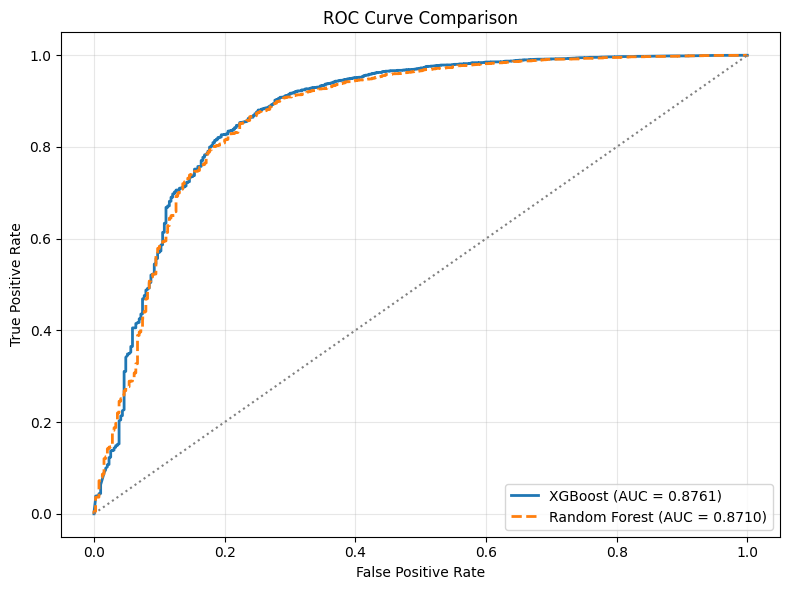

In [16]:
# --- ROC Curve: XGBoost vs Random Forest ---
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.4f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.4f})", linewidth=2, linestyle="--")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost 5-Fold Cross Validation
Fold scores: [0.86276676 0.8412404  0.87085838 0.85868844 0.86816419]
Mean AUC:    0.8603
Std AUC:     0.0104
Feature Importance (XGBoost):
bmi_age              0.258181
age_group            0.141767
high_bp              0.095158
general_health       0.083809
health_bmi           0.082939
high_cholesterol     0.072381
chol_bmi             0.044812
age_bp               0.042906
bmi                  0.040373
bmi_bp               0.038066
smoker               0.035029
physical_activity    0.032826
mental_health        0.031754
dtype: float32


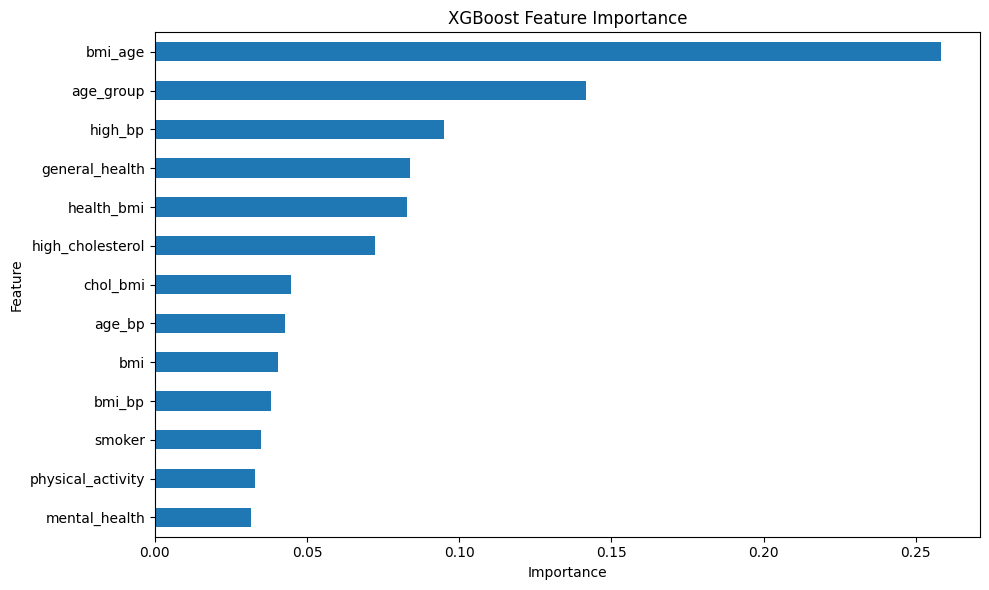

In [17]:
# --- XGBoost 5-Fold Cross Validation ---
from sklearn.model_selection import cross_val_score

xgb_cv = XGBClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

scores_xgb = cross_val_score(xgb_cv, X_numeric, y_numeric, cv=5, scoring="roc_auc")

print("XGBoost 5-Fold Cross Validation")
print("=" * 40)
print(f"Fold scores: {scores_xgb}")
print(f"Mean AUC:    {scores_xgb.mean():.4f}")
print(f"Std AUC:     {scores_xgb.std():.4f}")
# --- XGBoost Feature Importance ---
importance_xgb = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance (XGBoost):")
print("=" * 40)
print(importance_xgb)

plt.figure(figsize=(10, 6))
importance_xgb.plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (5.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 6.7 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.46.0-cp313-cp313-macosx_12_0_arm64.whl (37.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.0 MB/s  0:00:00 eta 0:00:01m
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [shap]5/7 [numba]te]
Note: you may need to restart the kernel to use updated packages.


In [40]:
# --- SHAP Explainability ---
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate log-odds): {explainer.expected_value:.4f}")

SHAP values shape: (7506, 13)
Expected value (base rate log-odds): -0.0015


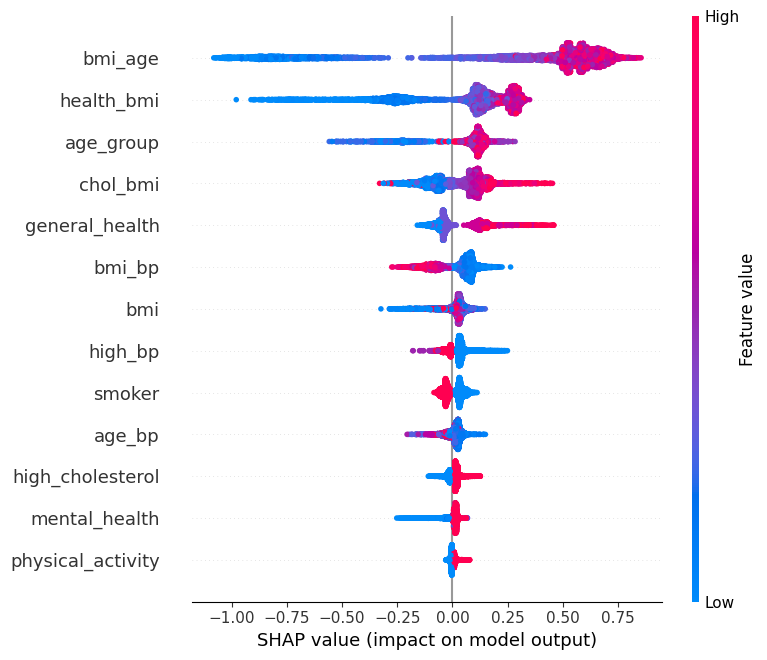

In [20]:
# --- SHAP Summary Plot (Global Feature Importance + Direction) ---
shap.summary_plot(shap_values, X_test, show=True)

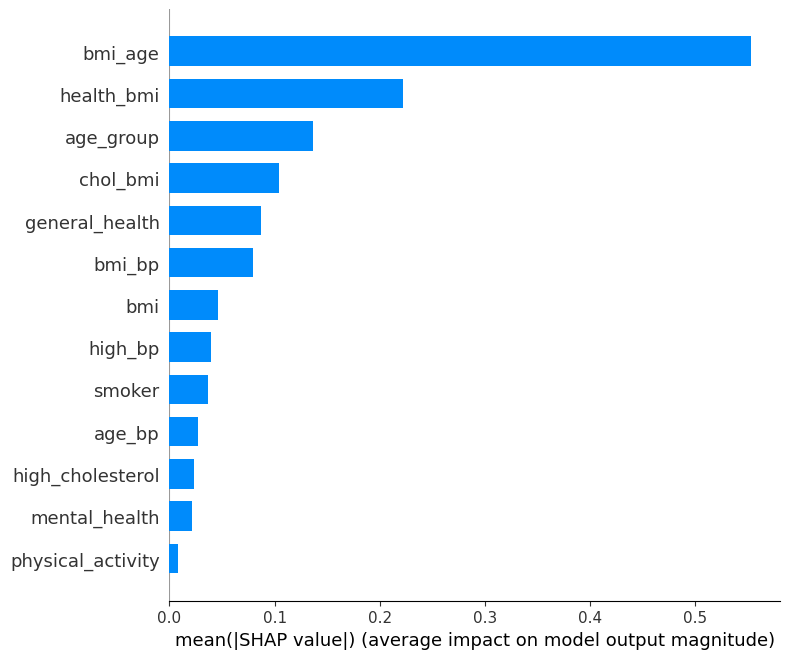

In [21]:
# --- SHAP Bar Plot (Mean Absolute Impact) ---
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

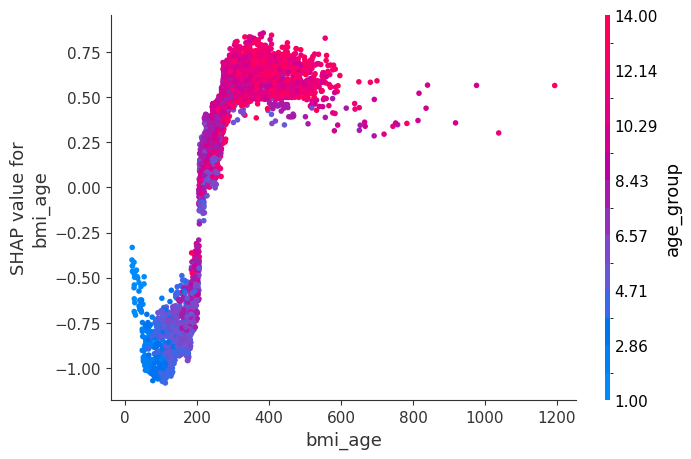

In [22]:
# --- SHAP Dependence Plot: BMI x Age Interaction ---
shap.dependence_plot("bmi_age", shap_values, X_test, interaction_index="age_group", show=True)

In [ ]:

# ============================================================
# DIABETES RISK CALCULATOR  (with Probability Calibration)
# ============================================================
import numpy as np
import pandas as pd
import shap

def predict_diabetes_risk(age_group, bmi, high_bp, smoker, high_cholesterol,
                          physical_activity, general_health, mental_health,
                          model=None, raw_model=xgb, explainer_obj=explainer):
    """
    Diabetes Risk Calculator with probability calibration.

    Parameters (clean 0/1 encoding):
        age_group:         1-13  (1=18-24 ... 13=80+)
        bmi:               e.g. 27.5
        high_bp:           1=Yes, 0=No
        smoker:            1=Yes, 0=No
        high_cholesterol:  1=Yes, 0=No
        physical_activity: 1=Active, 0=Inactive
        general_health:    1=Excellent ... 5=Poor
        mental_health:     0-30 (days poor mental health; 0=none)
        model:             Calibrated model (defaults to calibrated_xgb if available)
        raw_model:         Raw XGBoost for comparison
        explainer_obj:     SHAP TreeExplainer (uses raw model — SHAP scores unchanged)

    Returns:
        dict with calibrated risk percentage and top contributing factors
    """
    # Default to calibrated_xgb if it exists in scope, else fall back to raw
    if model is None:
        try:
            model = calibrated_xgb
        except NameError:
            model = raw_model

    features = {
        "bmi":               bmi,
        "age_group":         age_group,
        "high_bp":           high_bp,
        "smoker":            smoker,
        "high_cholesterol":  high_cholesterol,
        "physical_activity": physical_activity,
        "general_health":    general_health,
        "mental_health":     mental_health,
        "bmi_age":           bmi * age_group,
        "bmi_bp":            bmi * high_bp,
        "age_bp":            age_group * high_bp,
        "chol_bmi":          high_cholesterol * bmi,
        "health_bmi":        general_health * bmi,
    }

    input_df = pd.DataFrame([features]).astype(np.float64)

    # Calibrated probability
    risk_prob = model.predict_proba(input_df)[0, 1]

    # Raw probability for comparison
    raw_prob = raw_model.predict_proba(input_df)[0, 1]

    # SHAP explanation (always uses the underlying XGBoost raw model)
    shap_vals = explainer_obj.shap_values(input_df)[0]
    feat_names = list(features.keys())
    contributions = pd.Series(shap_vals, index=feat_names).sort_values(key=abs, ascending=False)

    # ── Risk level thresholds ──────────────────────────────────
    if risk_prob < 0.20:
        level = "LOW"
    elif risk_prob < 0.45:
        level = "MODERATE"
    else:
        level = "HIGH"

    print("=" * 52)
    print("   DIABETES RISK ASSESSMENT")
    print("=" * 52)
    print(f"\n   Estimated Diabetes Risk : {risk_prob:.2f}  ({risk_prob * 100:.1f}%)")
    print(f"   Risk Level              : {level}")
    print(f"   Model Confidence        : calibrated probability")
    print(f"   (Raw model score        : {raw_prob:.2f})")
    print(f"\n   Top Contributing Factors:")
    print("   " + "-" * 42)
    total_abs = sum(abs(contributions))
    for feat, val in contributions.head(5).items():
        direction  = "+" if val > 0 else "-"
        feat_label = feat.replace("_", " ").title()
        pct        = abs(val) / total_abs * 100
        print(f"   {direction} {feat_label:.<34} {pct:5.1f}%")
    print("\n" + "=" * 52)

    return {
        "calibrated_risk":  round(risk_prob, 4),
        "raw_risk":         round(raw_prob,  4),
        "risk_level":       level,
        "contributions":    contributions.to_dict(),
    }

print("Diabetes Risk Calculator (calibrated) ready.")


Diabetes Risk Calculator (calibrated) ready.


In [ ]:
# --- Example 1: High-risk patient ---
# 65-year-old, BMI 35, high BP, smoker, high cholesterol,
# inactive, poor health, 15 days poor mental health

result_high = predict_diabetes_risk(
    age_group=9,
    bmi=35.0,
    high_bp=1,
    smoker=1,
    high_cholesterol=1,
    physical_activity=0,
    general_health=5,
    mental_health=15
)

   DIABETES RISK ASSESSMENT

   Estimated Diabetes Risk : 1.00  (99.5%)
   Risk Level              : HIGH
   Model Confidence        : calibrated probability
   (Raw model score        : 0.71)

   Top Contributing Factors:
   ------------------------------------------
   + Bmi Age...........................  43.6%
   + Health Bmi........................  19.3%
   + General Health....................   8.6%
   + Age Group.........................   7.4%
   + High Bp...........................   4.9%



In [ ]:
# --- Example 2: Low-risk patient ---
# 30-year-old, BMI 22, no BP, non-smoker, no cholesterol issues,
# active, excellent health, no poor mental health days

result_low = predict_diabetes_risk(
    age_group=3,
    bmi=22.0,
    high_bp=0,
    smoker=0,
    high_cholesterol=0,
    physical_activity=1,
    general_health=1,
    mental_health=0
)

   DIABETES RISK ASSESSMENT

   Estimated Diabetes Risk : 0.48  (48.1%)
   Risk Level              : HIGH
   Model Confidence        : calibrated probability
   (Raw model score        : 0.26)

   Top Contributing Factors:
   ------------------------------------------
   - Bmi Age...........................  50.1%
   - Health Bmi........................  14.9%
   - Age Group.........................  10.4%
   - General Health....................   7.4%
   - High Bp...........................   6.7%



In [ ]:
# --- Example 3: Moderate-risk patient ---
# 50-year-old, BMI 28, no BP, non-smoker,
# high cholesterol, active, good health, 5 days poor mental health

result_mod = predict_diabetes_risk(
    age_group=7,
    bmi=28.0,
    high_bp=0,
    smoker=0,
    high_cholesterol=1,
    physical_activity=1,
    general_health=2,
    mental_health=5
)

   DIABETES RISK ASSESSMENT

   Estimated Diabetes Risk : 0.74  (74.0%)
   Risk Level              : HIGH
   Model Confidence        : calibrated probability
   (Raw model score        : 0.31)

   Top Contributing Factors:
   ------------------------------------------
   - Bmi Age...........................  43.5%
   - Age Group.........................  13.2%
   - General Health....................  11.3%
   - Health Bmi........................   8.8%
   - Chol Bmi..........................   5.1%



In [ ]:

# --- Export trained model + calibrator + ONNX for deployment ---
import joblib, os
import numpy as np

export_dir = os.path.expanduser("~/Desktop/Github REPO/Healthcare_risk_prediction/models")
os.makedirs(export_dir, exist_ok=True)

# ── Save sklearn artifacts ────────────────────────────────────────────────
joblib.dump(xgb, os.path.join(export_dir, "diabetes_xgboost.pkl"))
joblib.dump(iso_reg, os.path.join(export_dir, "isotonic_calibrator.pkl"))
joblib.dump(explainer, os.path.join(export_dir, "shap_explainer.pkl"))

# ── Save isotonic calibration as .npz for lightweight ONNX deployment ────
np.savez(
    os.path.join(export_dir, "isotonic_calibration.npz"),
    X_thresholds=np.array(iso_reg.X_thresholds_, dtype=np.float32),
    y_thresholds=np.array(iso_reg.y_thresholds_, dtype=np.float32),
)

# ── Export ONNX model for onnxruntime deployment ─────────────────────────
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

onnx_input = [("features", FloatTensorType([None, 13]))]
onnx_model = convert_sklearn(xgb, initial_types=onnx_input, target_opset=12)
onnx_path = os.path.join(export_dir, "diabetes_xgboost.onnx")
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Exported to", export_dir)
for f_name in sorted(os.listdir(export_dir)):
    size = os.path.getsize(os.path.join(export_dir, f_name))
    print(f"  {f_name:.<40} {size/1024:.0f} KB")
